In [832]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [833]:
from Base_Modules.Environments import Prison
from Prison_Strategies.Basic_Strategies import *
from Prison_Strategies.Reinforcement_Learning_Strategies import *
from Base_Modules.Game_Master import Game_Master
from Base_Modules.Action import Action_History, Prison_Actions, Duel_Matrix
import pandas as pd
from collections import defaultdict

In [834]:
prison = Prison()
actions = prison.Get_Actions()

In [835]:
q_learning = Q_Learning(actions=actions, state_size=4, register_enemy_ID=False)
q_learning.Train()
# q_learning.Load_Q_Table("dupa.pkl")

In [836]:
# q_learning.Save_Q_Table("dupa.pkl")

In [837]:
strategies_list = [
    Random_Strategy(actions=actions),
    q_learning,
    Random_Strategy(actions=actions, p_coop=0.1),
    Always_Betray(actions=actions),
    Always_Cooperate(actions=actions),
    Patient_Unforgiving(actions=actions),
    Copycat(actions=actions),
    Periodic(actions=actions, period=1),
    Forgiving(actions=actions),
]

number_of_strategies = len(strategies_list)

In [838]:
strategies = {}

for (i, s) in enumerate(strategies_list):
    strategies[i] = s
    s.Set_ID(i)

In [839]:
def Get_Index_By_Name(strategies : dict[int, Strategy], name : str) -> int:
    for ix, (id, s) in enumerate(strategies.items()):
        if str(s) == name:
            return id
    for ix, (id, s) in enumerate(strategies.items()):
        if  "".join(str(s).split(":")[1:]).startswith(name):
            return id
    for ix, (id, s) in enumerate(strategies.items()):
        if str(s).startswith(name):
            return id
    return -1

def get_name(id : int) -> str:
    return "".join(str(strategies[id]).split(":")[1:])


In [840]:
def Normal_Tournament(gm : Game_Master, number_of_games, total_games_explicit) -> tuple[Duel_Matrix, object]:
    return gm.Tournament(number_of_games, Game_Master.Game_Type.All_Vs_All, total_games_explicit=total_games_explicit)

def RL_Training(gm : Game_Master, number_of_games, number_of_RL_epochs, total_games_explicit) -> Game_Master:
    for i in range(number_of_RL_epochs):
        gm.Tournament(number_of_games, Game_Master.Game_Type.All_Vs_All, total_games_explicit=total_games_explicit)
        gm.Reset()
        if (i)%1000 == 0:
            print(i)
    return gm

In [841]:
number_of_games = 400
number_of_RL_epochs = 10000
total_games_explicit = True
max_action_memory = -1

gm = Game_Master(prison, strategies=strategies, duel_size=2, max_action_memory=max_action_memory)

q_learning.Train()
RL_Training(gm=gm, number_of_games=number_of_games+1, number_of_RL_epochs=number_of_RL_epochs, total_games_explicit=total_games_explicit)

gm.Reset()
q_learning.Eval()
duel_matrix, rewards = Normal_Tournament(gm=gm, number_of_games=number_of_games, total_games_explicit=total_games_explicit)
rewards.Sort_Total_Rewards()

0
1000
2000
3000
4000
5000
6000
7000
8000
9000


In [842]:
display(pd.DataFrame.from_dict(q_learning.q_table, orient="index"))

,0
"(Cooperate, Betray, Cooperate)",22.956176
"(Cooperate, Betray, Betray)",20.842379
"(Cooperate,)",22.874176
"(Betray, Betray, Cooperate)",20.778638
"(Betray, Betray, Betray)",22.642270
...,...
"(Cooperate, Cooperate, Betray, Cooperate, Cooperate, Betray, Betray)",0.000000
"(Betray, Cooperate, Betray, Betray, Betray, Cooperate, Cooperate)",1.574571
"(Betray, Cooperate, Betray, Betray, Betray, Cooperate, Betray)",0.000000
"(Betray, Betray, Betray, Betray, Betray, Cooperate, Cooperate)",3.092462


## Analiza


In [843]:
def Sort_Based_On_Total_Rewards(total_rewards, data):
    sorted_data = dict(sorted(
        data.items(),
        key=lambda kv: total_rewards.get(kv[0], 0),
        reverse=True
    ))
    return sorted_data

In [844]:
total_rewards = rewards.Get_Total_Rewards()
total_rewards_per_name = {str(strategies[i]):total_rewards[i] for i in total_rewards.keys()}

average_rewards_per_match = {k: (float(v)/number_of_strategies) for k, v in total_rewards.items()}
average_rewards_per_round = {k: (float(v)/(number_of_strategies*number_of_games)) for k, v in total_rewards.items()}

duel_rewards = rewards.Get_All_Duel_Rewards()

duel_rewards = dict(sorted(duel_rewards.items(), key=lambda kv: total_rewards.get(kv[0][0]), reverse=True))

In [845]:
largest_shared_victory = -float("inf")
least_shared_victory = float("inf")

for (_, rewards) in duel_rewards.items():
    largest_shared_victory = max(largest_shared_victory, sum(rewards.values()))
    least_shared_victory = min(least_shared_victory, sum(rewards.values()))


print(f"Largest shared reward: {largest_shared_victory}")
print(f"Least shared reward: {least_shared_victory}")


Largest shared reward: 2400
Least shared reward: 803


In [846]:
from Base_Modules.Nemesis import Nemesis_Best_Enemy_Score, Nemesis_Worst_Score, Nemesis_Largest_Difference

criterion = Nemesis_Worst_Score

nemesis = criterion.Get_Nemesis(duel_rewards=duel_rewards)
nemesis = Sort_Based_On_Total_Rewards(total_rewards=total_rewards, data=nemesis)
nemesis_per_name = criterion.Translate_Nemesis_To_Strategy_Names(strategies=strategies, nemesis=nemesis)

nemesis_df = pd.DataFrame(
    [(k, v[0]) for k, v in nemesis_per_name.items()],
    columns=["Strategy", "Its nemesis"]
)

In [847]:
from Base_Modules.Nemesis import Friend_Best_Total_Score, Friend_Best_Own_Score

criterion = Friend_Best_Own_Score

friends = criterion.Get_Nemesis(duel_rewards=duel_rewards)
friends = Sort_Based_On_Total_Rewards(total_rewards=total_rewards, data=friends)
friends_per_name = criterion.Translate_Nemesis_To_Strategy_Names(strategies=strategies, nemesis=friends)

friends_df = pd.DataFrame(
    [(k, v[0]) for k, v in friends_per_name.items()],
    columns=["Strategy", "Its friend"]
)

In [848]:
cooperate_stats_per_strategy = {}
for s in strategies.keys():
    stats = duel_matrix.Get_Action_Statistics_Of_Strategy(s)
    cooperate_stats_per_strategy[s] = stats[Prison_Actions.Cooperate]/sum(stats.values())

action_stats_df = pd.DataFrame(
    [(get_name(s), v) for s,v in cooperate_stats_per_strategy.items()],
    columns=["Strategy", "% Coop"]
)
# display(action_stats_df.round(2))

## Wyniki

In [849]:
summary = {}
for ix, (id, score) in enumerate(total_rewards.items()):
    summary[ix] = {"Name": get_name(id),
                   "Average score": average_rewards_per_round[id],
                   "Nemesis": get_name(nemesis[id][0]),
                   "Friend": get_name(friends[id][0]),
                   "% Coop": cooperate_stats_per_strategy[id],
                    }

summary_df = pd.DataFrame.from_dict(summary, orient="index")
summary_df.index.name = "Place"

display(summary_df.round(2))

## 8 -> 1.36 dla ss=2, True
## 4 -> 1.87 dla ss=2, False

,Name,Average score,Nemesis,Friend,% Coop
Place,,,,,
0,Patient_Unforgiving (patience=1),2.18,Always_Betray,Copycat (1st=Cooperate),0.38
1,Forgiving (p_forgive=0.1),2.13,Always_Betray,Patient_Unforgiving (patience=1),0.45
2,Copycat (1st=Cooperate),2.08,Always_Betray,Patient_Unforgiving (patience=1),0.59
3,Always_Betray,2.03,Patient_Unforgiving (patience=1),Always_Cooperate,0.00
4,Random_Strategy (p_coop=0.1),1.96,Always_Betray,Always_Cooperate,0.10
5,Q_Learning,1.62,Always_Betray,Always_Cooperate,0.44
6,Periodic (period=1),1.58,Always_Betray,Always_Cooperate,0.50
7,Random_Strategy (p_coop=0.5),1.57,Always_Betray,Always_Cooperate,0.50
8,Always_Cooperate,1.42,Always_Betray,Patient_Unforgiving (patience=1),1.00


## Dataframes

In [850]:
average_reward_per_round_df = pd.DataFrame.from_dict(average_rewards_per_round, orient="index", columns=["Average Reward"])
average_reward_per_round_df.index.name = "Strategy Name"
average_reward_per_round_df = average_reward_per_round_df.round(3)

In [851]:
# Per match

average_reward_per_match_df = pd.DataFrame.from_dict(average_rewards_per_match, orient="index", columns=["Average Reward"])
average_reward_per_match_df.index.name = "Strategy Name"
average_reward_per_match_df = average_reward_per_match_df.round(3)

In [852]:
strat_names = [str(strategies[s]) for s in total_rewards.keys()]

score_matrix = pd.DataFrame(index=strat_names, columns=strat_names, dtype=object)

coof = number_of_games

for (s1, s2), scores in duel_rewards.items():
    score_matrix.loc[str(strategies[s2]), str(strategies[s1])] = (scores[s2]/coof, scores[s1]/coof)
    score_matrix.loc[str(strategies[s1]), str(strategies[s2])] = (scores[s1]/coof, scores[s2]/coof)

for s in strat_names:
    score_matrix.loc[s, s] = (0, 0)

In [853]:
sum_matrix = pd.DataFrame(index=strat_names, columns=strat_names, dtype=object)

for (s1, s2), scores in duel_rewards.items():
    sum_matrix.loc[str(strategies[s2]), str(strategies[s1])] = (scores[s2] + scores[s1])
    sum_matrix.loc[str(strategies[s1]), str(strategies[s2])] = (scores[s2] + scores[s1])

for s in strat_names:
    sum_matrix.loc[s, s] = 0

In [854]:
victory_matrix = score_matrix.apply(lambda col: col.map(lambda x: int(x[0] > x[1])))
for s in strat_names:
    victory_matrix.loc[s, s] = float("NaN")

In [855]:
def color_cell(x):
    if not isinstance(x, tuple):
        return ""
    if x[0] == 0 and x[1] == 0:
        return "background-color: black"
    elif x[0] > x[1]:
        return "background-color: green"
    elif x[0] < x[1]:
        return "background-color: darkred"
    else:
        return "background-color: gray"

styled_score_matrix = (
    score_matrix.style
    .map(color_cell)
    .set_properties(**{
        "border": "1px solid black"
    })
    .set_table_styles([
        {"selector": "th", "props": [("border", "2px solid black")]},
        {"selector": "td", "props": [("border", "2px solid black")]}
    ])
)

display(styled_score_matrix)

,(5):Patient_Unforgiving (patience=1),(8):Forgiving (p_forgive=0.1),(6):Copycat (1st=Cooperate),(3):Always_Betray,(2):Random_Strategy (p_coop=0.1),(1):Q_Learning,(7):Periodic (period=1),(0):Random_Strategy (p_coop=0.5),(4):Always_Cooperate
(5):Patient_Unforgiving (patience=1),"(0, 0)","(3.0, 3.0)","(3.0, 3.0)","(0.9975, 1.01)","(1.3175, 0.93)","(2.3325, 0.6825)","(2.9925, 0.5175)","(2.9575, 0.52)","(3.0, 3.0)"
(8):Forgiving (p_forgive=0.1),"(3.0, 3.0)","(0, 0)","(3.0, 3.0)","(0.8825, 1.47)","(1.3625, 1.15)","(2.295, 1.1575)","(2.84, 0.9275)","(2.8075, 1.12)","(3.0, 3.0)"
(6):Copycat (1st=Cooperate),"(3.0, 3.0)","(3.0, 3.0)","(0, 0)","(0.9975, 1.01)","(1.3325, 1.345)","(2.58, 2.58)","(2.495, 2.5075)","(2.2975, 2.2975)","(3.0, 3.0)"
(3):Always_Betray,"(1.01, 0.9975)","(1.47, 0.8825)","(1.01, 0.9975)","(0, 0)","(1.37, 0.9075)","(2.35, 0.6625)","(3.0, 0.5)","(3.05, 0.4875)","(5.0, 0.0)"
(2):Random_Strategy (p_coop=0.1),"(0.93, 1.3175)","(1.15, 1.3625)","(1.345, 1.3325)","(0.9075, 1.37)","(0, 0)","(2.7025, 0.915)","(2.85, 0.825)","(2.93, 0.8675)","(4.785, 0.3225)"
(1):Q_Learning,"(0.6825, 2.3325)","(1.1575, 2.295)","(2.58, 2.58)","(0.6625, 2.35)","(0.915, 2.7025)","(0, 0)","(2.0, 2.625)","(2.0275, 2.49)","(4.595, 0.6075)"
(7):Periodic (period=1),"(0.5175, 2.9925)","(0.9275, 2.84)","(2.5075, 2.495)","(0.5, 3.0)","(0.825, 2.85)","(2.625, 2.0)","(0, 0)","(2.295, 2.2075)","(4.0, 1.5)"
(0):Random_Strategy (p_coop=0.5),"(0.52, 2.9575)","(1.12, 2.8075)","(2.2975, 2.2975)","(0.4875, 3.05)","(0.8675, 2.93)","(2.49, 2.0275)","(2.2075, 2.295)","(0, 0)","(4.13, 1.305)"
(4):Always_Cooperate,"(3.0, 3.0)","(3.0, 3.0)","(3.0, 3.0)","(0.0, 5.0)","(0.3225, 4.785)","(0.6075, 4.595)","(1.5, 4.0)","(1.305, 4.13)","(0, 0)"


In [856]:
import webbrowser
store_styled_matrix_in_html = False
if store_styled_matrix_in_html:
    styled_score_matrix.to_html("styled_score_matrix.html")
    webbrowser.open_new_tab("styled_score_matrix.html")

## Wykresy


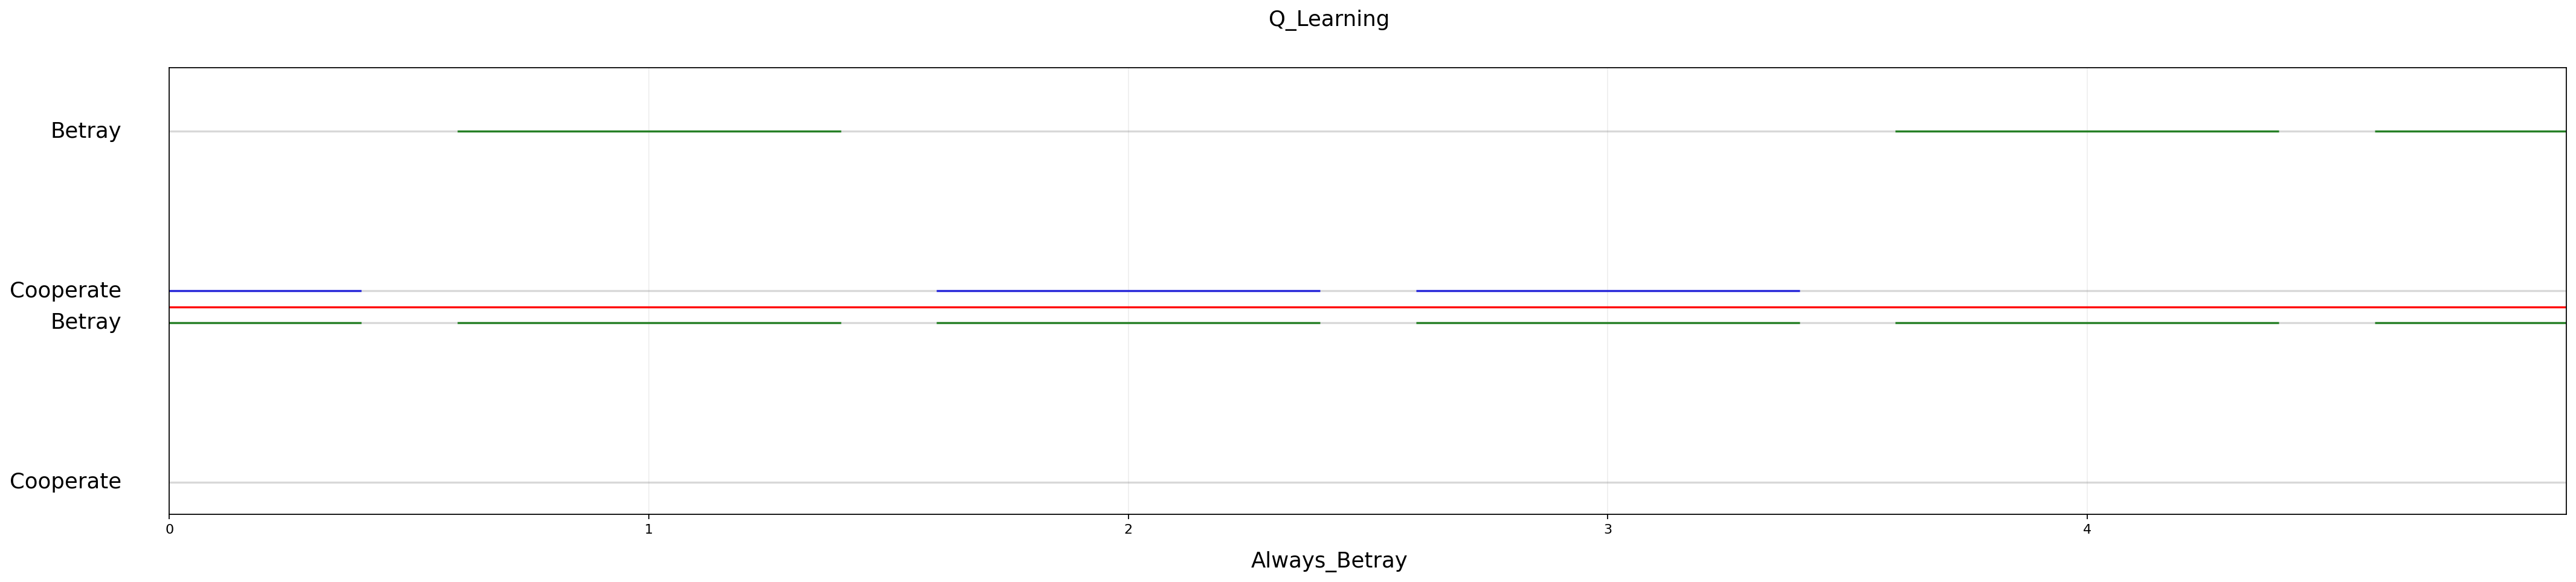

In [857]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

x_min = 0
x_max = 5
strategy1_name = "Al"
strategy2_name = "Q"

strategy1_ID = Get_Index_By_Name(strategies=strategies, name=strategy1_name)
strategy2_ID = Get_Index_By_Name(strategies=strategies, name=strategy2_name)

assert(strategy1_ID>=0 and strategy2_ID>=0), "Strategy not found."

fontsize=16

smin = min(strategy1_ID, strategy2_ID)
smax = max(strategy1_ID, strategy2_ID)

strategy1_ID = smin
strategy2_ID = smax

data = duel_matrix.Get_Action_History((strategy1_ID, strategy2_ID)).Get_Action_History()

fig = plt.figure(figsize=(32, 6), dpi=160)
y_scale = 0.5
y_offset = 0.6

for i, (key, values) in enumerate(data.items()):
    y, c = [v.value*y_scale - y_offset*i for v in values], ["b" if v.value==0 else "g" for v in values]
    x = list(range(len(y)))

    # plt.step(x, y, where='post', label=f"Signal {key}")
    # plt.scatter(x, y, label=f"Signal {key}")
    for i, val in enumerate(y):
        plt.hlines(val, float(float(i)-0.4), float(float(i)+0.4), colors=[c[i]])

plt.hlines(y = -0.05, xmin=x_min, xmax=x_max, colors=["r"], linestyles="-")
plt.hlines(y = 0, xmin=x_min, xmax=x_max, colors="gray", linestyles="-", alpha=0.3)
plt.hlines(y = y_scale, xmin=x_min, xmax=x_max, colors="gray", linestyles="-", alpha=0.3)
plt.hlines(y = y_scale-y_offset, xmin=x_min, xmax=x_max, colors="gray", linestyles="-", alpha=0.3)
plt.hlines(y = -y_offset, xmin=x_min, xmax=x_max, colors="gray", linestyles="-", alpha=0.3)

plt.xlim([x_min, x_max])
plt.ylim([-y_offset-0.1, y_offset+0.1])
plt.yticks([])
plt.ylabel("")
plt.suptitle(f"{get_name(strategy1_ID)}", fontsize=fontsize, ha="center")


ax = plt.gca()

ax.text(-0.02, 0, 'Cooperate', transform=ax.get_yaxis_transform(),
        va='center', ha='right', fontsize=fontsize)
ax.text(-0.02, y_scale, 'Betray', transform=ax.get_yaxis_transform(),
        va='center', ha='right', fontsize=fontsize)

ax.text(-0.02, y_scale-y_offset, 'Betray', transform=ax.get_yaxis_transform(),
        va='center', ha='right', fontsize=fontsize)
ax.text(-0.02, -y_offset, 'Cooperate', transform=ax.get_yaxis_transform(),
        va='center', ha='right', fontsize=fontsize)


fig.text(0.5, 0.01, f"{get_name(strategy2_ID)}", ha='center', va='bottom', fontsize=fontsize)

ax.set_xticks(np.arange(x_min, x_max, 1))
ax.grid(True, alpha=0.2)

plt.show()